# Multiple Quantum Wells and Finite Superlattices

This notebook processes the results generated by next**nano**++ for the simulation of finite superlattices, as outlined in Paul Harrison's book [Quantum Wells, Wires and Dots (2nd e.d)](https://www.wiley.com/en-us/Quantum+Wells%2C+Wires+and+Dots%3A+Theoretical+and+Computational+Physics+of+Semiconductor+Nanostructures%2C+4th+Edition-p-9781118923368). The section refered to is titled "Multiple Quantum Wells and Finite Superlattices" (Section 3.10, pp. 95-96)

In that section, $N$ repeats of 40Å GaAs / 40Å Ga<sub>0.8</sub>Al<sub>0.2</sub>As sandwiched between 200Å Ga<sub>0.8</sub>Al<sub>0.2</sub>As on the left and right. We will designate the coordinate $x=0$ as the start of the first well.

## nextnanopy features covered
This tutorial covers the following features of <code>nextnanopy</code>:
* Setting up and executing a sweeping variable
* Navgating the <code>DataFolder</code> output class to obtain the necessary values for plotting
* Plotting graphs with matplotlib
* Replacing a variable's value in an input file

## Python libraries used

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import nextnanopy as nn
from nextnanopy.utils.plotting import use_nxt_style
import os
import re
from pathlib import Path
%matplotlib inline

# use nextnano style for plotting
use_nxt_style()

## Checking the configuration of nextnanopy

The path directories in the config file must be set up. If they are not, refer to the [tutorial on setting up config files](https://github.com/nextnanopy/nextnanopy/blob/master/docs/examples/Example0_Set_up_the_configuration.ipynb).

In [2]:
software = 'nextnano++'
nn.config.config[software]

{'exe': 'C:\\Program Files\\nextnano\\2025_12_20\\nextnano++\\bin\\nextnano++_Intel_64bit.exe',
 'license': 'C:\\Users\\Heorhii\\Documents\\nextnano\\License\\License_nnp.lic',
 'database': 'C:\\Users\\Heorhii\\source\\Workspaces\\nextnanoplus\\nextnano\\database\\database.nnp',
 'outputdirectory': 'C:\\Users\\Heorhii\\Documents\\nextnano\\OutputNnpy',
 'threads': 0}

We want to obtain all the paths, so we set up a simple function to aid us.

In [3]:
def get_directories(software):
    try:
        return nn.config.config[software]
    except:
        raise KeyError(f'Software name not recognised. Please choose one of: {list(nn.config.config.keys())}')

exe, license, database, output_folder, threads = list(get_directories('nextnano++').values())

## Setting up the sweeping variable

We will sweep through the variables using <code>nextnanopy</code>. We define
* The input folder
* The filename
* The variable of interest
* The values to be swept over. In this case, we want to simulate $2\leq N \leq 10$ wells

We will utilise <code>nextnanopy</code>'s <code>Sweep</code> class to aid in the sweeping of variables.

In [4]:
input_folder = r'C:\Program Files\nextnano\2025_12_20\nextnano++\examples'
filename = r'Superlattice_N_Wells_nnp.nnp'
filepath = Path(input_folder) / filename
variable_name = 'NUMBER_OF_WELLS'
variable_values = np.arange(2,11,1)

sweep_variables = {variable_name: variable_values}
#We can always increase the size of the dictionary if we have
#more variables we want to sweep over.

In [5]:
sweep = nn.Sweep(sweep_variables, filepath)
print(sweep)

Sweep
fullpath: C:\Program Files\nextnano\2025_12_20\nextnano++\examples\Superlattice_N_Wells_nnp.nnp
Input variables: 0 elements


In [6]:
sweep.save_sweep(temp=True)

### Alternative way of getting the list of values
In next**nano**++, some variables already have a list of values or a range of values set up. This can be grabbed from the raw input file with the following functions

In [7]:
def grab_list_variables(input_file, variable_name):
    c = input_file.variables[variable_name].comment
    try:
        return np.array(list(map(float, re.search(r'(ListOfValues:)(.*?)\)', c).group(2).split(','))))
    except:
            raise ValueError("No list of values found for variable in input file. Check that variable has ListOfValues in comment or manually create a list of values.")
            
def grab_range_variables(input_file, variable_name):
    c = input_file.variables[variable_name].comment
    try:
        return np.array(list(map(float, re.search(r'(RangeOfValues:)(.*?)\)', c).group(2).split(','))))
    except:
            raise ValueError("No range of values found for variable in input file. Check that variable has RangeOfValues in comment or manually create a list of values.")     

For example, if we wanted to get the default list of values for the <code>$NUMBER_OF_WELLS</code> variable in next**nano**++, we may do the following.

In [8]:
input_file = nn.InputFile(filepath)

In [9]:
grab_list_variables(input_file, "NUMBER_OF_WELLS")

array([ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

We will now execute the input file with the list of variables

In [10]:
sweep.execute_sweep(show_log=False)


Executing simulations [1/9]...

Executing simulations [2/9]...

Executing simulations [3/9]...

Executing simulations [4/9]...

Executing simulations [5/9]...

Executing simulations [6/9]...

Executing simulations [7/9]...

Executing simulations [8/9]...

Executing simulations [9/9]...


 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:         742         841
      

Computing densities...

******  SOLVING QUANTUM-CURRENT-POISSON EQUATIONS *----------------------------
*----  Terminates after:   max_iter = 1000
                        residual =       1.000000000e+06[carriers/cm^2]
                        residual_fermi = 1.000000000e-08
Set Fermi level range: -0 -0

QUANTUM-CURRENT-POISSON:  iteration = 1 of 1000 ----------------------------

Current-repetition:   iteration = 1 of 2 -------------

Calculating electron mobility...
Calculating hole mobility...
Calculating variable recombination and generation...
Calculating fixed generation/recombination/injection...

Solving electron current equation(s)...

Solving hole current equation(s)...

Computing densities...

Current-Density:   Residual_EFermilevel = 0.000000000e+00   Residual_HFermilevel = 0.000000000e+00

Current-repetition:   iteration = 2 of 2 -------------


Material database initialized.

Checking license:
	 Valid From: 2022-1-1 To: 2022-12-31
	 Licensed to: E-mail: brandon.loke@nextnano.com-2022-12-31-de-0000-00-nxt3

********* SETUP SIMULATION *****************************************************

NOTE: Using output directory specified from command line (nextnanomat), 

NOTE: Setting output directory to: D:\nextnano output\Superlattice_N_Wells_sweep__NUMBER_OF_WELLS\Superlattice_N_Wells__NUMBER_OF_WELLS_7_\

********* Simulation Grid *********

Creating grid 1 using:
    pos = -21     	spacing = 1
    pos = -20     	spacing = 0.1
    pos = 72     	spacing = 0.1
    pos = 73     	spacing = 0.1

Grid dimension: 932 * 1 * 1 
Number of unique grid points: 932
Range in 1-direction:   -21 , ... , 73


********* Rotation Matrix *********
 1.0000000,  0.0000000,  0.0000000
 0.0000000,  1.0000000,  0.0000000
 0.0000000,  0.0000000,  1.0000000

********* Periodicity *************
  0-direction:  not periodic


Start initializing structure.
Finis

  Newton achieved/desired residual: 1.74306238e-12 1.80951265e-10

Solving Quantum Mechanics ---- (and calculate density)

  valence band maximum: -0.794876818
  conduction band minimum: 0.627605325

 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:           1          70
      
 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:         672         921
      
 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:         852         921
      
 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:         822         921
      

Computing densities...

QUANTUM-CURRENT-POISSON:   Residual_EDensity = 1.038767264e-12      Residual_HDensity = 9.732498233e-14
QUANTUM-CURRENT-POISSON:   Residual_EFermilevel = 0.000000000e+00   Residual_HFermilevel = 0.000000000e+00
QUANTUM-CURRENT-POISSON:   Residual_Pote

      
 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:         932        1001
      
 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:         902        1001
      

Computing densities...

******  SOLVING QUANTUM-CURRENT-POISSON EQUATIONS *----------------------------
*----  Terminates after:   max_iter = 1000
                        residual =       1.000000000e+06[carriers/cm^2]
                        residual_fermi = 1.000000000e-08
Set Fermi level range: -0 -0

QUANTUM-CURRENT-POISSON:  iteration = 1 of 1000 ----------------------------

Current-repetition:   iteration = 1 of 2 -------------

Calculating electron mobility...
Calculating hole mobility...
Calculating variable recombination and generation...
Calculating fixed generation/recombination/injection...

Solving electron current equation(s)...

Solving hole current equation(s)...

Computing densities...

Current-Density:


Material database initialized.

Checking license:
	 Valid From: 2022-1-1 To: 2022-12-31
	 Licensed to: E-mail: brandon.loke@nextnano.com-2022-12-31-de-0000-00-nxt3

********* SETUP SIMULATION *****************************************************

NOTE: Using output directory specified from command line (nextnanomat), 

NOTE: Setting output directory to: D:\nextnano output\Superlattice_N_Wells_sweep__NUMBER_OF_WELLS\Superlattice_N_Wells__NUMBER_OF_WELLS_9_\

********* Simulation Grid *********

Creating grid 1 using:
    pos = -21     	spacing = 1
    pos = -20     	spacing = 0.1
    pos = 88     	spacing = 0.1
    pos = 89     	spacing = 0.1

Grid dimension: 1092 * 1 * 1 
Number of unique grid points: 1092
Range in 1-direction:   -21 , ... , 89


********* Rotation Matrix *********
 1.0000000,  0.0000000,  0.0000000
 0.0000000,  1.0000000,  0.0000000
 0.0000000,  0.0000000,  1.0000000

********* Periodicity *************
  0-direction:  not periodic


Start initializing structure.
Fin

  Newton achieved/desired residual: 1.94540056e-12 1.80951265e-10

Solving Quantum Mechanics ---- (and calculate density)

  valence band maximum: -0.794876818
  conduction band minimum: 0.627605325

 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:           1          70
      
 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:         832        1081
      
 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:        1012        1081
      
 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:         982        1081
      

Computing densities...

QUANTUM-CURRENT-POISSON:   Residual_EDensity = 7.274679208e-13      Residual_HDensity = 1.690708802e-13
QUANTUM-CURRENT-POISSON:   Residual_EFermilevel = 0.000000000e+00   Residual_HFermilevel = 0.000000000e+00
QUANTUM-CURRENT-POISSON:   Residual_Pote

      
 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:        1092        1161
      
 Solving 1 exact 1-band Schroedinger equation(s):
    Tridiagonal real symmetric eigenvalue solver:        1062        1161
      

Computing densities...

******  SOLVING QUANTUM-CURRENT-POISSON EQUATIONS *----------------------------
*----  Terminates after:   max_iter = 1000
                        residual =       1.000000000e+06[carriers/cm^2]
                        residual_fermi = 1.000000000e-08
Set Fermi level range: -0 -0

QUANTUM-CURRENT-POISSON:  iteration = 1 of 1000 ----------------------------

Current-repetition:   iteration = 1 of 2 -------------

Calculating electron mobility...
Calculating hole mobility...
Calculating variable recombination and generation...
Calculating fixed generation/recombination/injection...

Solving electron current equation(s)...

Solving hole current equation(s)...

Computing densities...

Current-Density:

We can obtain the output directory of the results and use the <code>DataFile</code> class to navigate its structure

In [11]:
sweep.sweep_output_directory

'C:\\Users\\Heorhii\\Documents\\nextnano\\OutputNnpy\\Superlattice_N_Wells_nnp_sweep__NUMBER_OF_WELLS4'

In [12]:
sweep_folder = nn.DataFolder(sweep.sweep_output_directory)

In [13]:
sweep_folder.show_tree(deep=False)

Superlattice_N_Wells_nnp_sweep__NUMBER_OF_WELLS4/
    Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_10_/
    Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_2_/
    Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_3_/
    Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_4_/
    Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_5_/
    Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_6_/
    Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_7_/
    Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_8_/
    Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_9_/
    sweep_info.txt
    sweep_infodict.json


Lets see the structure in one of the simualtion folders. sweep_folder.folders is a list of DataFolders

In [14]:
sweep_folder.folders[0].show_tree(deep=True)

Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_10_/
    Strain/
        hydrostatic_strain.dat
        strain_simulation.dat
    Structure/
        alloy_composition.dat
        material_indices.txt
        materials.dat
        regions_all.dat
        regions_material.dat
    bias_00000/
        OpticsSemiClassical/
            absorption_coeff_spectrum_THz.dat
            absorption_coeff_spectrum_cm-1.dat
            absorption_coeff_spectrum_eV.dat
            absorption_coeff_spectrum_nm.dat
            gain_spectrum_THz.dat
            gain_spectrum_cm-1.dat
            gain_spectrum_eV.dat
            gain_spectrum_nm.dat
            im_epsilon_spectrum_THz.dat
            im_epsilon_spectrum_cm-1.dat
            im_epsilon_spectrum_eV.dat
            im_epsilon_spectrum_nm.dat
            local_emission_photons.dat
            local_emission_power.dat
            spont_emission_spectrum_photons_THz.dat
            spont_emission_spectrum_photons_cm-1.dat
            spont_emission_s

## Plotting the $\Gamma$ band edges

We obtain the x coordinates and the gamma bandedge values with the following lines

In [15]:
datafile =  nn.DataFile(sweep_folder.go_to('Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_2_', 'bias_00000', 'bandedges.dat'), product = software)
x = datafile.coords['x'].value
gamma = datafile.variables['Gamma'].value

Before we plot the $\Gamma$ energies against $x$, we check that the dimensions are identical

In [16]:
np.size(x) == np.size(gamma)

True

In [17]:
fig, ax = plt.subplots()
ax.plot(x, gamma)

## Recreating Harrison's Figures
Harrison's figures take the bottom of the quantum well to be at 0 potential. Differences in how next**nano**++ calculates the band edges result in a different offset in the values outputted by the software.

We will first obtain the offset with

In [18]:
bandedgeoffset = np.amin(gamma[30:-30]) #Values chosen to avoid the 0 value at the start and end
bandedgeoffset

0.62760528959006

If the offset is known before hand, one can use <code>numpy</code> array manipulation to apply a function on the array

In [19]:
gamma_shift = gamma - bandedgeoffset

### Finding groundstate energies

To find the groundstate energies as a function of the number of wells, we will create a simple function to iterate over all the $N$ wells. The groundstate energies are found in the <code>Quantum</code> subfolder. We first demonstrate how to obtain the groundstate energies for the $N=2$ case and then a way to get the groundstate energies for all $N$ values

In [20]:
df_energy = nn.DataFile(sweep_folder.go_to('Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_2_', 
                                 'bias_00000', 'Quantum', "quantum_region", 'Gamma', "energy_spectrum_k00000.dat"), 
                                    product = software)

df_energy.variables[0].value[0]

0.708045674934

Every different value of $N$ outputs a different output folder. 
We can use the **Sweep.sweep_output_infodict** to acess the correspondance between the value of $N$ and path to output folder.
sweep_output_infodict has a structure:
    {"path_ot_output_folder1" : {"VarA" : valA1, "VarB": valB1... },
     "path_ot_output_folder2" : {"VarA" : valA2, "VarB": valB2... },
     ...
     }
    

In [21]:
output_folders = []
N_vals = []
for folder_path, combination in sweep.sweep_output_infodict.items():
    output_folders.append(folder_path)
    N_val = combination["NUMBER_OF_WELLS"]
    N_vals.append(N_val)

We now want to store the first eigenstate energies into a single array so that it can be plotted alongside the number of wells. We can obtain all the energies with a simple function.

In [22]:
def get_all_energies(output_folders):
    arr = np.array([])
    for output_folder in output_folders:
        energy = (nn.DataFile(nn.DataFolder(output_folder).go_to( 
                                 'bias_00000', 'Quantum', "quantum_region", 'Gamma', "energy_spectrum_k00000.dat"), 
                                    product = software).variables[0].value[0] - bandedgeoffset) * 1000
        ##we shift the values downwards by the bandedgeoffset
        ##we also multiply by 1000 to convert from eV to meV
        arr = np.append(arr, energy)
    return arr

groundstate_energies = get_all_energies(output_folders)
groundstate_energies

array([80.44038534, 77.86490916, 76.64476868, 75.97489256, 75.56863317,
       75.30402713, 75.12219697, 74.99192859, 74.89543471])

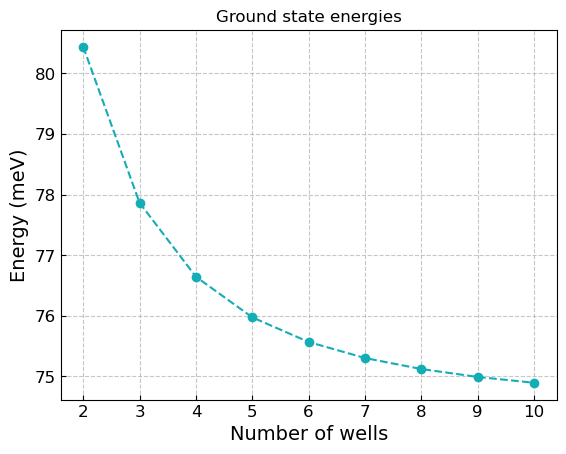

In [23]:
fig, ax = plt.subplots()
ax.plot(N_vals, groundstate_energies, 'o--')
# ax.grid(visible = True)
ax.set_ylabel('Energy (meV)')
ax.set_xlabel('Number of wells')
ax.set_title('Ground state energies')

fig
# plt.savefig('./Images/EnergyVsN.png', dpi = 2000)

### Wavefunctions in a finite superlattice
The first case has the following parameters:
* 40Å GaAs / 40Å Ga<sub>0.8</sub>Al<sub>0.2</sub>As sandwiched between 200Å Ga<sub>0.8</sub>Al<sub>0.2</sub>As on the left and right.
* 10 wells
* 4nm quantum wells
* 4nm barriers

**Getting the wavefunction and the x coordinates** <br>
We will plot 3 lowest states over the bandedges

Note that we cannot use the x-coordinates found in <code>bandedges.dat</code> for <code>amplitudes_shift_k00000.dat</code> because the dimensions of the array are not equal. We therefore have to plot the following pairs:
* Amplitude of the wavefunction and its corresponding x coordinates
* Bandedge and its corresponding x coordinates

In [24]:
# choose the folder with the 4 nm barrier

dfolder = nn.DataFolder(output_folders[2])
dfolder

DataFolder
fullpath: C:\Users\Heorhii\Documents\nextnano\OutputNnpy\Superlattice_N_Wells_nnp_sweep__NUMBER_OF_WELLS4\Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_4_
Folders: 3
Strain
Structure
bias_00000
Files:
['Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_4_.log', 'Superlattice_N_Wells_nnp__NUMBER_OF_WELLS_4_.nnp', 'bias_points.log', 'grid_x.dat', 'job_done.txt', 'simulation_database.txt', 'simulation_info.txt', 'simulation_input.txt', 'summary.log', 'variables_database.txt', 'variables_input.txt']

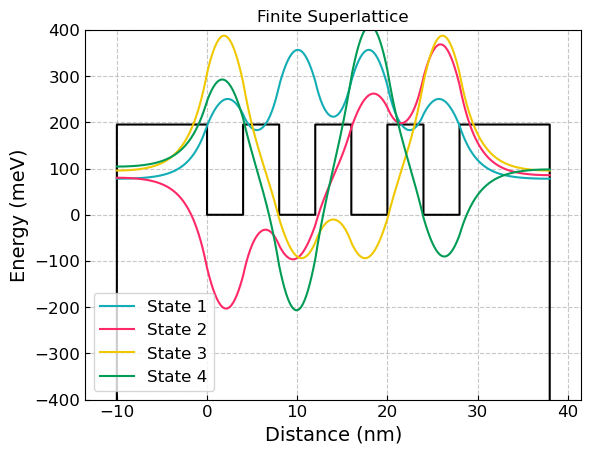

In [25]:
# get the bandedge
df_bandedge = nn.DataFile(dfolder.go_to('bias_00000', 'bandedges.dat'), 
            product = software)

bandedge = (df_bandedge.variables['Gamma'].value - bandedgeoffset) * 1000 # convert to meV
x_bandedge = df_bandedge.coords['x'].value

# get the wavefunctions 
df_wf = nn.DataFile(dfolder.go_to('bias_00000', 'Quantum', "quantum_region", "Gamma", 'amplitudes_shift_k00000.dat'), 
            product = software)

x_wf = df_wf.coords['x'].value

# plot
fig, ax = plt.subplots()
ax.plot(x_bandedge, bandedge, color="black")

for i in range(1, 5): # 1, 2, 3, 4
    wf = (df_wf.variables[f'Psi_{i}'].value - bandedgeoffset) * 1000
    ax.plot(x_wf, wf, label=f"State {i}")

ax.set_ylim(-400,400)
ax.set_xlabel('Distance (nm)')
ax.set_ylabel('Energy (meV)')
ax.set_title('Finite Superlattice')
ax.legend()
fig

### Wavefunction in a multiple quantum well system

The second case plotted has the following parameters:
* 100Å GaAs / 100Å Ga<sub>0.6</sub>Al<sub>0.4</sub>As sandwiched between 500Å Ga<sub>0.6</sub>Al<sub>0.4</sub>As on the left and right.
* 4 wells
* 10nm quantum wells
* 50nm barriers

Note that Ga<sub>x</sub>Al<sub>1-x</sub>As used here is different from the earlier graph plotted.

The alloy composition and the thickness of the barriers and the quantum wells are different in this example. We will use nextnanopy to change the variables and output the result.

In [26]:
input_file.fullpath

WindowsPath('C:/Program Files/nextnano/2025_12_20/nextnano++/examples/Superlattice_N_Wells_nnp.nnp')

In [27]:
input_file.variables.keys()

odict_keys(['TEMPERATURE', 'WELL_WIDTH', 'BARRIER_WIDTH', 'NUMBER_OF_WELLS', 'SUPERLATTICE_WIDTH', 'LEFT_BARRIER_WIDTH', 'RIGHT_BARRIER_WIDTH', 'FINE_GRID_SPACING', 'COARSE_GRID_SPACING', 'ALLOY_X'])

We want to change
* <code>WELl_WIDTH</code>
* <code>BARRIER_WIDTH</code>
* <code>LEFT_BARRIER_WIDTH</code>
* <code>RIGHT_BARRIER_WIDTH</code>
* <code>NUMBER_OF_WELLS</code>

In addition to this, we will save this new input file into the output folder.

In [28]:
input_file.set_variable(name = "WELL_WIDTH", value = 10)
input_file.set_variable(name = "BARRIER_WIDTH", value = 50)
input_file.set_variable(name = "LEFT_BARRIER_WIDTH" , value = 50)
input_file.set_variable(name = "RIGHT_BARRIER_WIDTH" , value = 50)
input_file.set_variable(name = "NUMBER_OF_WELLS", value = 4)


my_input_file_new = os.path.join(output_folder, r'Superlattice_N_Wells_WF2' + ".in")
input_file.save(my_input_file_new, overwrite = True, automkdir = True)

'C:\\Users\\Heorhii\\Documents\\nextnano\\OutputNnpy\\Superlattice_N_Wells_WF2.in'

We now create a function to run the input file and ouput the result

In [29]:
input_file.execute(show_log=False)

{'process': <Popen: returncode: 0 args: '"C:\\Program Files\\nextnano\\2025_12_20\\nextn...>,
 'outputdirectory': 'C:\\Users\\Heorhii\\Documents\\nextnano\\OutputNnpy\\Superlattice_N_Wells_WF2',
 'filename': 'Superlattice_N_Wells_WF2',
 'logfile': 'C:\\Users\\Heorhii\\Documents\\nextnano\\OutputNnpy\\Superlattice_N_Wells_WF2\\Superlattice_N_Wells_WF2.log',
 'cmd': '"C:\\Program Files\\nextnano\\2025_12_20\\nextnano++\\bin\\nextnano++_Intel_64bit.exe" --license "C:\\Users\\Heorhii\\Documents\\nextnano\\License\\License_nnp.lic" --database "C:\\Users\\Heorhii\\source\\Workspaces\\nextnanoplus\\nextnano\\database\\database.nnp" --threads 0 --outputdirectory "C:\\Users\\Heorhii\\Documents\\nextnano\\OutputNnpy\\Superlattice_N_Wells_WF2" --noautooutdir "C:\\Users\\Heorhii\\Documents\\nextnano\\OutputNnpy\\Superlattice_N_Wells_WF2.in"',
 'wdir': 'C:\\Program Files\\nextnano\\2025_12_20\\nextnano++\\bin',
 'queue': <queue.Queue at 0x1787bd05940>,
 'tout': <Thread(Thread-33 (read_output), stop

In [30]:
input_file.folder_output

'C:\\Users\\Heorhii\\Documents\\nextnano\\OutputNnpy\\Superlattice_N_Wells_WF2'

In [31]:
dfolder = nn.DataFolder(input_file.folder_output)

We will plot the same figure for this simulation as above. 

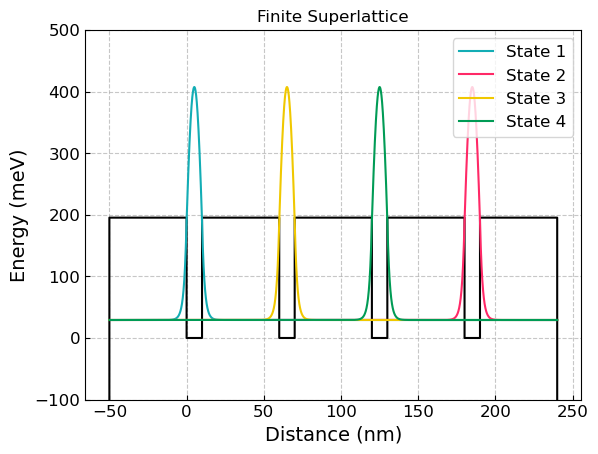

In [32]:
# get the bandedge
df_bandedge = nn.DataFile(dfolder.go_to('bias_00000', 'bandedges.dat'), 
            product = software)

bandedge = (df_bandedge.variables['Gamma'].value - bandedgeoffset) * 1000 # convert to meV
x_bandedge = df_bandedge.coords['x'].value

# get the wavefunctions 
df_wf = nn.DataFile(dfolder.go_to('bias_00000', 'Quantum', "quantum_region", "Gamma", 'amplitudes_shift_k00000.dat'), 
            product = software)

x_wf = df_wf.coords['x'].value

# plot bandedge
fig, ax = plt.subplots()
ax.plot(x_bandedge, bandedge, color="black")

for i in range(1, 5): # 1, 2, 3, 4
    wf = (df_wf.variables[f'Psi_{i}'].value - bandedgeoffset) * 1000
    ax.plot(x_wf, wf, label=f"State {i}")

ax.set_ylim(-100,500)
ax.set_xlabel('Distance (nm)')
ax.set_ylabel('Energy (meV)')
ax.set_title('Finite Superlattice')
ax.legend()
fig

In the case of wide barriers, we obtain a system of "independent" quntum wells with degenerate states